# 1 · The LoRaWAN Antwerp dataset

**Series:** reproducing *Keleşoğlu, Halama & Strzoda, "Enhancing LoRa-Based Outdoor
Localization Accuracy Using Machine Learning", IEEE Access 13 (2025), doi:10.1109/ACCESS.2025.3589032.*

| Notebook | Topic |
|---|---|
| **1 · Dataset** ← you are here | what is in the data, and why fingerprinting works |
| 2 · Preprocessing | −200 dBm handling, log transform, scaling, splits, feature vectors |
| 3 · Models | the seven models: theory, code and the paper's hyperparameters |
| 4 · Results | reproduced numbers next to the paper's, CDFs, error maps, timing |

### What problem are we solving?
A LoRaWAN end device sends an uplink packet. Every gateway in range receives it and reports
the **RSSI** (received signal strength, dBm). For each message we therefore get a vector

$$\mathbf{r} = [\,\mathrm{RSSI}_1, \dots, \mathrm{RSSI}_G\,],$$

with a placeholder value for gateways that did not hear it. **Fingerprinting** treats this
vector as a signature of the place it was sent from. In an offline phase we collect
(fingerprint, GPS position) pairs. Online, we learn a regression
$f:\mathbf{r}\mapsto(\text{lat},\text{lon})$. No gateway coordinates, no path-loss model and no
time synchronisation are needed, which is why this approach suits low-cost LPWAN networks.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `lora_loc` importable from notebooks/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lora_loc import config, data, preprocessing as pp, features, geo, plotting
plotting.style()
pd.set_option("display.precision", 2)

## 1.1 Load the data and check it

We use version **1.2** of the Zenodo record *Sigfox and LoRaWAN Datasets for Fingerprint
Localization in Large Urban and Rural Areas* (Aernouts et al., doi:10.5281/zenodo.3342253).
Messages were sent by GPS-equipped trackers on postal vehicles in Antwerp. First we check
that our file is byte-identical to the published one.

In [2]:
print("file :", config.CSV_FILE.name)
print("MD5 matches Zenodo v1.2:", data.verify(config.CSV_FILE))
df = data.load_csv()
print("shape:", df.shape)
df.head()

file : lorawan_antwerp_2019_dataset.csv
MD5 matches Zenodo v1.2: True


shape: (130429, 77)


,BS 1,BS 2,BS 3,BS 4,BS 5,BS 6,BS 7,BS 8,BS 9,BS 10,...,BS 68,BS 69,BS 70,BS 71,BS 72,RX Time,SF,HDOP,Latitude,Longitude
0,-200,-200,-200,-117,-114,-200,-119,-200,-112,-200,...,-200,-200,-200,-200,-200,2019-01-11T11:27:31.534+01:00,8,0.75,51.23,4.43
1,-200,-200,-200,-200,-200,-200,-200,-200,-200,-200,...,-200,-115,-200,-200,-200,2019-01-15T09:55:04.560+01:00,7,0.64,51.21,4.40
2,-200,-100,-200,-200,-200,-200,-200,-200,-200,-119,...,-200,-200,-200,-200,-200,2019-01-03T12:06:00.983+01:00,11,0.84,51.20,4.41
3,-200,-200,-200,-200,-200,-200,-200,-200,-200,-200,...,-200,-200,-200,-200,-200,2019-01-23T08:13:58.520215889+01:00,7,0.62,51.20,4.39
4,-200,-200,-200,-200,-200,-200,-200,-200,-200,-200,...,-200,-200,-200,-200,-200,2019-01-29T17:20:20.826210335+01:00,7,0.66,51.22,4.41


There are **130,429 messages × 77 columns**:

* `BS 1` … `BS 72`: RSSI (dBm) at each of the 72 gateways; **−200 means "not received"**,
* `RX Time`: timestamp of reception,
* `SF`: LoRa spreading factor (7–12), chosen by adaptive data rate (ADR),
* `HDOP`: horizontal dilution of precision of the GPS fix (a quality indicator for the ground truth),
* `Latitude`, `Longitude`: the ground truth, which is our regression target.

## 1.2 How many gateways actually hear anything?

In [3]:
bs = data.rssi_columns(df)
active = data.active_gateways(df)
dead = sorted(set(bs) - set(active), key=lambda c: int(c.split()[1]))
print(f"{len(bs)} gateway columns, {len(active)} active, {len(dead)} never receive a message")
print("dead:", ", ".join(dead))

72 gateway columns, 44 active, 28 never receive a message
dead: BS 8, BS 13, BS 21, BS 24, BS 26, BS 28, BS 29, BS 30, BS 36, BS 38, BS 39, BS 40, BS 42, BS 45, BS 46, BS 51, BS 54, BS 56, BS 57, BS 58, BS 61, BS 62, BS 63, BS 64, BS 65, BS 66, BS 67, BS 68


28 gateway columns are −200 in *every* row, so they carry no information and are dropped.
This leaves the **44 gateways** used in the paper. Next: how often each gateway receives,
and how many gateways receive each message.

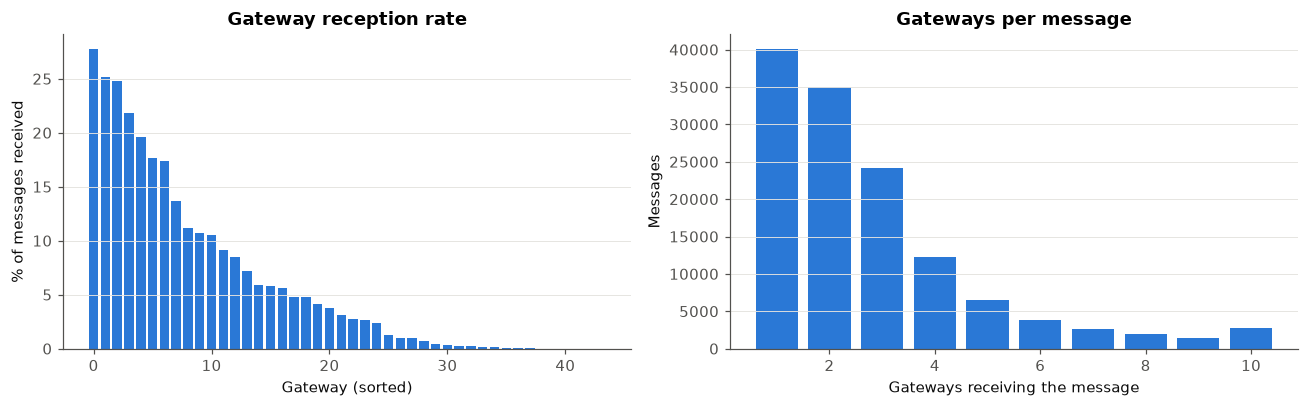

gateways per message: mean 2.76, median 2, max 10; heard by only one gateway: 30.7%


In [4]:
received = df[active] != config.NO_SIGNAL_DBM
per_gw = received.mean().sort_values(ascending=False) * 100
per_msg = received.sum(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(range(len(per_gw)), per_gw.values, color=plotting.MODEL_COLORS["k-NN"], width=0.8)
ax[0].set(xlabel="Gateway (sorted)", ylabel="% of messages received",
          title="Gateway reception rate")
ax[0].grid(axis="x", visible=False)
counts = per_msg.value_counts().sort_index()
ax[1].bar(counts.index, counts.values, color=plotting.MODEL_COLORS["k-NN"], width=0.8)
ax[1].set(xlabel="Gateways receiving the message", ylabel="Messages",
          title="Gateways per message")
ax[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
print(f"gateways per message: mean {per_msg.mean():.2f}, median {per_msg.median():.0f}, "
      f"max {per_msg.max()}; heard by only one gateway: {(per_msg == 1).mean():.1%}")

**Takeaway.** The fingerprints are **very sparse**: on average a message reaches fewer than 3 of the
44 gateways (93.7 % of the RSSI matrix is "no signal"), and about 31 % of messages reach a single gateway, and then the fingerprint only says
"somewhere in that gateway's coverage area". This alone puts a floor of a few hundred metres
under the error of *any* RSSI-only method. Keep it in mind when reading the results.

## 1.3 RSSI and spreading-factor distributions

observed RSSI range: [-127, -60] dBm -> nothing between -200 and -127 dBm


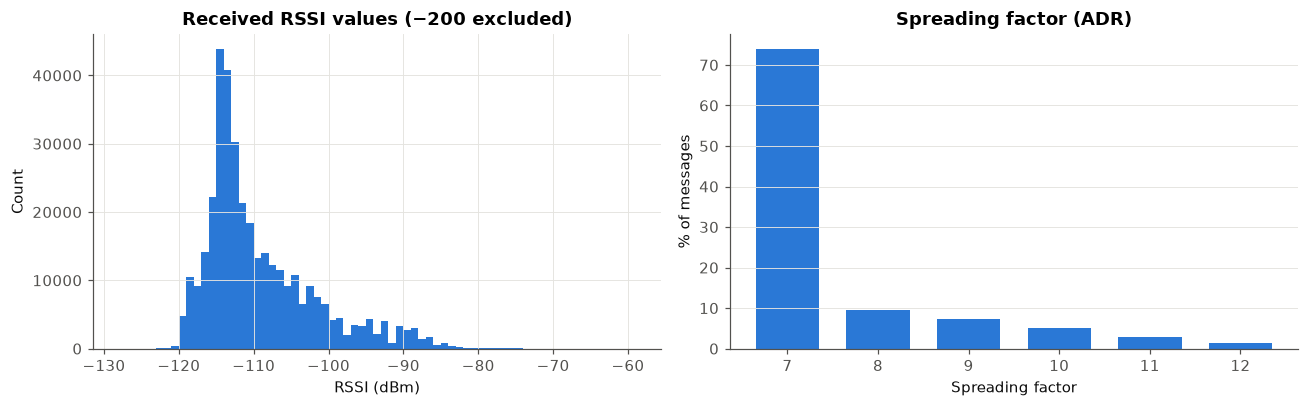

In [5]:
vals = df[active].to_numpy().ravel()
vals = vals[vals != config.NO_SIGNAL_DBM]
print(f"observed RSSI range: [{vals.min()}, {vals.max()}] dBm "
      f"-> nothing between -200 and {vals.min()} dBm")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(vals, bins=np.arange(-128, -58, 1), color=plotting.MODEL_COLORS["k-NN"])
ax[0].set(xlabel="RSSI (dBm)", ylabel="Count", title="Received RSSI values (−200 excluded)")
sf = df["SF"].value_counts().sort_index()
ax[1].bar(sf.index, sf.values / len(df) * 100, color=plotting.MODEL_COLORS["k-NN"], width=0.7)
ax[1].set(xlabel="Spreading factor", ylabel="% of messages", title="Spreading factor (ADR)")
ax[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

* RSSI lies between −127 and −60 dBm and piles up near the receiver sensitivity. The large gap
  down to the −200 placeholder is why notebook 2 replaces −200 with **−128 dBm**, not with a
  value far away.
* Most traffic uses SF7. A high SF usually means the device was far from gateways or poorly
  covered, so SF carries some location information. This is the motivation for FV2 = RSSI + SF.

## 1.4 Where were the messages sent from?

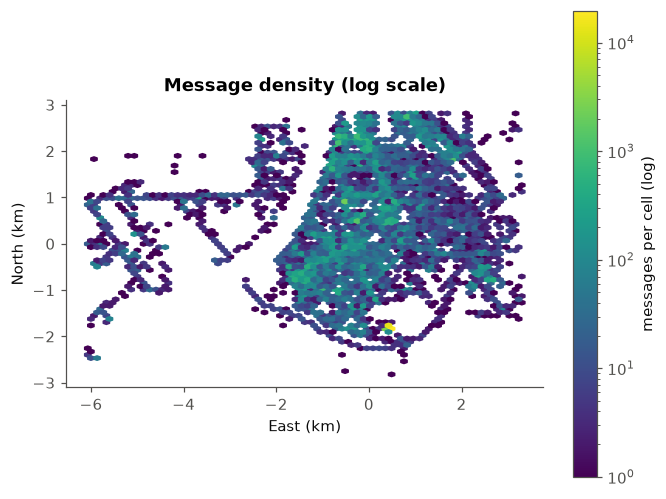

lat [51.1853, 51.2360], lon [4.3252, 4.4598]; extent ≈ 9.4 km × 5.6 km


In [6]:
x, y = geo.to_local_xy_m(df.Latitude, df.Longitude)
fig, ax = plt.subplots(figsize=(7, 5.5))
hb = ax.hexbin(x / 1000, y / 1000, gridsize=70, bins="log", cmap="viridis", mincnt=1)
ax.set(xlabel="East (km)", ylabel="North (km)", title="Message density (log scale)", aspect="equal")
ax.grid(False); plt.colorbar(hb, ax=ax, label="messages per cell (log)")
plt.show()
print(f"lat [{df.Latitude.min():.4f}, {df.Latitude.max():.4f}], "
      f"lon [{df.Longitude.min():.4f}, {df.Longitude.max():.4f}]; "
      f"extent ≈ {(x.max()-x.min())/1000:.1f} km × {(y.max()-y.min())/1000:.1f} km")

The messages follow the vehicles' routes through the city streets, so coverage is uneven.
Streets that are driven often are sampled densely, and other areas are barely sampled. This
matters for data-driven methods: a model can only interpolate where it has seen fingerprints.

## 1.5 A note on ground-truth quality (HDOP)

In [7]:
print(df["HDOP"].describe(percentiles=[.5, .9, .99]).round(2).to_string())
print(f"messages with HDOP > 2: {(df.HDOP > 2).sum()}")

count    130429.00
mean          3.61
std         617.54
min           0.00
50%           0.66
90%           0.78
99%           1.05
max      171019.00
messages with HDOP > 2: 715


Nearly all fixes have HDOP < 1, which means good GPS geometry, but a few are extreme outliers.
The paper does not filter on HDOP, so neither do we. That choice is part of reproducing the
paper faithfully. Removing the outliers would be a reasonable improvement for your own work.

**Summary.** 130,429 messages, 44 useful gateways, sparse fingerprints, RSSI in [−127, −60] dBm.
→ Continue with **notebook 2**.